# Phase 2 - Data Preprocessing

## Objectives

In this phase, the dataset is cleaned and transformed to improve data quality and prepare it for statistical analysis and machine learning.

### Tasks Performed

- Handle missing values
- Remove duplicate records
- Check incorrect data types
- Handle invalid values
- Detect and treat outliers
- Encode categorical variables
- Normalize and standardize data
- Apply data transformations
- Perform feature engineering
- Compare dataset before and after preprocessing

The cleaned dataset generated in this phase will be used for Exploratory Data Analysis (EDA), Statistical Testing, and the Flask Analytics Dashboard.

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv("hotel_bookings.csv")
print("Dataset Shape Before Cleaning")
print(df.shape)
df.isnull().sum()

Dataset Shape Before Cleaning
(119390, 32)


hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [8]:
missing = (df.isnull().sum()/len(df))*100

missing = missing.sort_values(ascending=False)

missing

company                           94.306893
agent                             13.686238
country                            0.408744
children                           0.003350
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                       0.000000
hotel                              0.000000
previous_cancellations             0.000000
days_in_waiting_list               0.000000
customer_type                      0.000000
adr                                0.000000
required_car_parking_spaces        0.000000
total_of_special_requests          0.000000
reservation_status                 0.000000
previous_bookings_not_canceled     0.000000
is_repeated_guest                  0.000000
is_canceled                        0.000000
distribution_channel               0.000000
market_segment                     0.000000
meal                               0.000000
babies                          

In [11]:
df["children"].fillna(df["children"].median(), inplace=True)
df["agent"].fillna(0, inplace=True)
df["agent"].fillna(0, inplace=True)
df["country"].fillna(df["country"].mode()[0], inplace=True)
df["company"].fillna(0, inplace=True)

In [12]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [13]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 32013


In [15]:
# Remove Duplicates
df.drop_duplicates(inplace=True)
print("Dataset Shape After Removing Duplicates")

print(df.shape)

Dataset Shape After Removing Duplicates
(87377, 32)


In [16]:
df["reservation_status_date"] = pd.to_datetime(
    df["reservation_status_date"]
)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87377 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87377 non-null  object        
 1   is_canceled                     87377 non-null  int64         
 2   lead_time                       87377 non-null  int64         
 3   arrival_date_year               87377 non-null  int64         
 4   arrival_date_month              87377 non-null  object        
 5   arrival_date_week_number        87377 non-null  int64         
 6   arrival_date_day_of_month       87377 non-null  int64         
 7   stays_in_weekend_nights         87377 non-null  int64         
 8   stays_in_week_nights            87377 non-null  int64         
 9   adults                          87377 non-null  int64         
 10  children                        87377 non-null  float64       
 11  babies

In [18]:
#INVALID VALUES & OUTLIERS
df[
    (df["adults"]==0) &
    (df["children"]==0) &
    (df["babies"]==0)
]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,No Deposit,0.0,174.0,0,Transient-Party,0.00,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,No Deposit,0.0,174.0,0,Transient,0.00,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,No Deposit,38.0,0.0,0,Transient-Party,0.00,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,No Deposit,308.0,0.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,No Deposit,308.0,0.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115029,City Hotel,0,107,2017,June,26,27,0,3,0,...,No Deposit,7.0,0.0,0,Transient,100.80,0,0,Check-Out,2017-06-30
115091,City Hotel,0,1,2017,June,26,30,0,1,0,...,No Deposit,0.0,0.0,0,Transient,0.00,1,1,Check-Out,2017-07-01
116251,City Hotel,0,44,2017,July,28,15,1,1,0,...,No Deposit,425.0,0.0,0,Transient,73.80,0,0,Check-Out,2017-07-17
116534,City Hotel,0,2,2017,July,28,15,2,5,0,...,No Deposit,9.0,0.0,0,Transient-Party,22.86,0,1,Check-Out,2017-07-22


In [19]:
df = df[
    (df["adults"]+df["children"]+df["babies"])>0
]

In [20]:
print(df.shape)

(87211, 32)


In [21]:
num_cols = df.select_dtypes(
    include=["int64","float64"]
).columns

num_cols

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

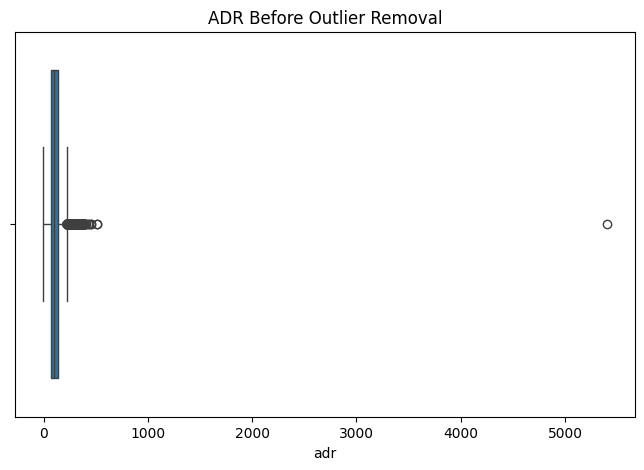

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["adr"]
)

plt.title("ADR Before Outlier Removal")

plt.show()

In [23]:
Q1 = df["adr"].quantile(0.25)

Q3 = df["adr"].quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

print(lower)

print(upper)
df = df[
    (df["adr"]>=lower) &
    (df["adr"]<=upper)
]

-20.52499999999999
226.875


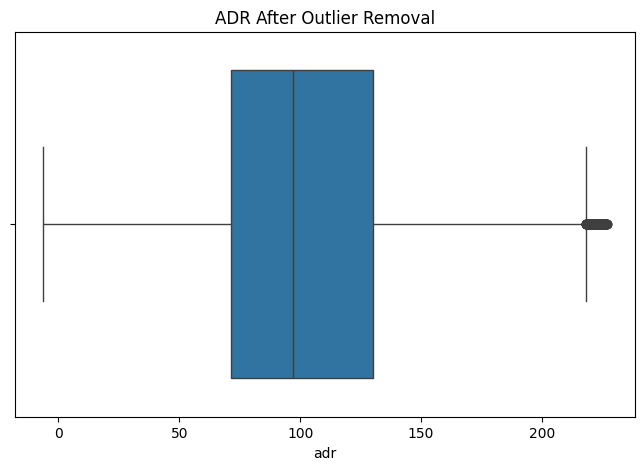

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["adr"]
)

plt.title("ADR After Outlier Removal")

plt.show()

In [26]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df[num_cols]))

z_scores

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
0,0.611218,3.027127,1.749009,0.020449,1.673535,0.973303,1.277959,0.208096,0.282928,0.093358,0.202165,0.083287,0.107446,3.866391,0.723560,0.206535,0.075512,2.264472,0.294911,0.838181
1,0.611218,7.595084,1.749009,0.020449,1.673535,0.973303,1.277959,0.208096,0.282928,0.093358,0.202165,0.083287,0.107446,5.280345,0.723560,0.206535,0.075512,2.264472,0.294911,0.838181
2,0.611218,0.846963,1.749009,0.020449,1.673535,0.973303,0.788612,1.397114,0.282928,0.093358,0.202165,0.083287,0.107446,0.375468,0.723560,0.206535,0.075512,0.598424,0.294911,0.838181
3,0.611218,0.777577,1.749009,0.020449,1.673535,0.973303,0.788612,1.397114,0.282928,0.093358,0.202165,0.083287,0.107446,0.375468,2.063814,0.206535,0.075512,0.598424,0.294911,0.838181
4,0.611218,0.766012,1.749009,0.020449,1.673535,0.973303,0.299264,0.208096,0.282928,0.093358,0.202165,0.083287,0.107446,0.375468,1.476998,0.206535,0.075512,0.087503,0.294911,0.369866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,0.611218,0.661932,1.166781,0.599817,1.605966,0.972178,1.168778,0.208096,0.282928,0.093358,0.202165,0.083287,0.107446,0.375468,2.889023,0.206535,0.075512,0.128821,0.294911,0.838181
119386,0.611218,0.251659,1.166781,0.599817,1.719053,0.972178,1.168778,1.813307,0.282928,0.093358,0.202165,0.083287,0.107446,0.375468,0.641039,0.206535,0.075512,2.743224,0.294911,1.577913
119387,0.611218,0.534723,1.166781,0.599817,1.719053,0.972178,1.168778,0.208096,0.282928,0.093358,0.202165,0.083287,0.107446,0.375468,0.641039,0.206535,0.075512,1.238894,0.294911,3.994008
119388,0.611218,0.332610,1.166781,0.599817,1.719053,0.972178,1.168778,0.208096,0.282928,0.093358,0.202165,0.083287,0.107446,0.375468,0.092480,0.206535,0.075512,0.054667,0.294911,0.838181


In [28]:
outliers = (z_scores > 3).sum()

print(outliers)
print("Final Dataset Shape")

print(df.shape)

is_canceled                          0
lead_time                         1007
arrival_date_year                    0
arrival_date_week_number             0
arrival_date_day_of_month            0
stays_in_weekend_nights            280
stays_in_week_nights              1484
adults                             274
children                          2808
babies                             857
is_repeated_guest                 3326
previous_cancellations             276
previous_bookings_not_canceled     739
booking_changes                   1381
agent                              694
company                           2471
days_in_waiting_list               642
adr                                  0
required_car_parking_spaces       6908
total_of_special_requests          325
dtype: int64
Final Dataset Shape
(84705, 32)


In [29]:
df.to_csv(
    "cleaned_hotel_bookings.csv",
    index=False
)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


In [31]:
processed_df = df.copy()
#lebel Enciding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

label_cols = [
    "hotel",
    "arrival_date_month",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "assigned_room_type",
    "deposit_type",
    "customer_type",
    "reservation_status"
]

for col in label_cols:
    processed_df[col] = le.fit_transform(processed_df[col].astype(str))

In [32]:
processed_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,0,342,2015,5,27,1,0,0,2,...,0,0.0,0.0,0,2,0.0,0,0,1,2015-07-01
1,1,0,737,2015,5,27,1,0,0,2,...,0,0.0,0.0,0,2,0.0,0,0,1,2015-07-01
2,1,0,7,2015,5,27,1,0,1,1,...,0,0.0,0.0,0,2,75.0,0,0,1,2015-07-02
3,1,0,13,2015,5,27,1,0,1,1,...,0,304.0,0.0,0,2,75.0,0,0,1,2015-07-02
4,1,0,14,2015,5,27,1,0,2,2,...,0,240.0,0.0,0,2,98.0,0,1,1,2015-07-03


In [33]:
onehot_df = pd.get_dummies(
    df,
    columns=["hotel","customer_type"],
    drop_first=True
)

onehot_df.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,hotel_Resort Hotel,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0,342,2015,July,27,1,0,0,2,0.0,...,0,0.0,0,0,Check-Out,2015-07-01,True,False,True,False
1,0,737,2015,July,27,1,0,0,2,0.0,...,0,0.0,0,0,Check-Out,2015-07-01,True,False,True,False
2,0,7,2015,July,27,1,0,1,1,0.0,...,0,75.0,0,0,Check-Out,2015-07-02,True,False,True,False
3,0,13,2015,July,27,1,0,1,1,0.0,...,0,75.0,0,0,Check-Out,2015-07-02,True,False,True,False
4,0,14,2015,July,27,1,0,2,2,0.0,...,0,98.0,0,1,Check-Out,2015-07-03,True,False,True,False


In [34]:
num_cols = processed_df.select_dtypes(include=["int64","float64"]).columns

In [35]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

normalized_df = processed_df.copy()

normalized_df[num_cols] = minmax.fit_transform(normalized_df[num_cols])

normalized_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,0.0,0.464043,0.0,5,0.5,0.0,0.0,0.00,0.036364,...,0,0.000000,0.0,0.0,2,0.027356,0.0,0.0,1,2015-07-01
1,1,0.0,1.000000,0.0,5,0.5,0.0,0.0,0.00,0.036364,...,0,0.000000,0.0,0.0,2,0.027356,0.0,0.0,1,2015-07-01
2,1,0.0,0.009498,0.0,5,0.5,0.0,0.0,0.02,0.018182,...,0,0.000000,0.0,0.0,2,0.348941,0.0,0.0,1,2015-07-02
3,1,0.0,0.017639,0.0,5,0.5,0.0,0.0,0.02,0.018182,...,0,0.568224,0.0,0.0,2,0.348941,0.0,0.0,1,2015-07-02
4,1,0.0,0.018996,0.0,5,0.5,0.0,0.0,0.04,0.036364,...,0,0.448598,0.0,0.0,2,0.447560,0.0,0.2,1,2015-07-03


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

standardized_df = processed_df.copy()

standardized_df[num_cols] = scaler.fit_transform(standardized_df[num_cols])

standardized_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,-0.611218,3.027127,-1.749009,5,0.020449,-1.673535,-0.973303,-1.277959,0.208096,...,0,-0.723560,-0.206535,-0.075512,2,-2.264472,-0.294911,-0.838181,1,2015-07-01
1,1,-0.611218,7.595084,-1.749009,5,0.020449,-1.673535,-0.973303,-1.277959,0.208096,...,0,-0.723560,-0.206535,-0.075512,2,-2.264472,-0.294911,-0.838181,1,2015-07-01
2,1,-0.611218,-0.846963,-1.749009,5,0.020449,-1.673535,-0.973303,-0.788612,-1.397114,...,0,-0.723560,-0.206535,-0.075512,2,-0.598424,-0.294911,-0.838181,1,2015-07-02
3,1,-0.611218,-0.777577,-1.749009,5,0.020449,-1.673535,-0.973303,-0.788612,-1.397114,...,0,2.063814,-0.206535,-0.075512,2,-0.598424,-0.294911,-0.838181,1,2015-07-02
4,1,-0.611218,-0.766012,-1.749009,5,0.020449,-1.673535,-0.973303,-0.299264,0.208096,...,0,1.476998,-0.206535,-0.075512,2,-0.087503,-0.294911,0.369866,1,2015-07-03


In [37]:
log_df = processed_df.copy()

log_df["adr"] = np.log1p(log_df["adr"])

log_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,0,342,2015,5,27,1,0,0,2,...,0,0.0,0.0,0,2,0.000000,0,0,1,2015-07-01
1,1,0,737,2015,5,27,1,0,0,2,...,0,0.0,0.0,0,2,0.000000,0,0,1,2015-07-01
2,1,0,7,2015,5,27,1,0,1,1,...,0,0.0,0.0,0,2,4.330733,0,0,1,2015-07-02
3,1,0,13,2015,5,27,1,0,1,1,...,0,304.0,0.0,0,2,4.330733,0,0,1,2015-07-02
4,1,0,14,2015,5,27,1,0,2,2,...,0,240.0,0.0,0,2,4.595120,0,1,1,2015-07-03


In [38]:
from scipy.stats import boxcox

boxcox_df = processed_df.copy()

boxcox_df["lead_time"], lam = boxcox(boxcox_df["lead_time"] + 1)

print("Lambda :", lam)

Lambda : 0.23818309892225034


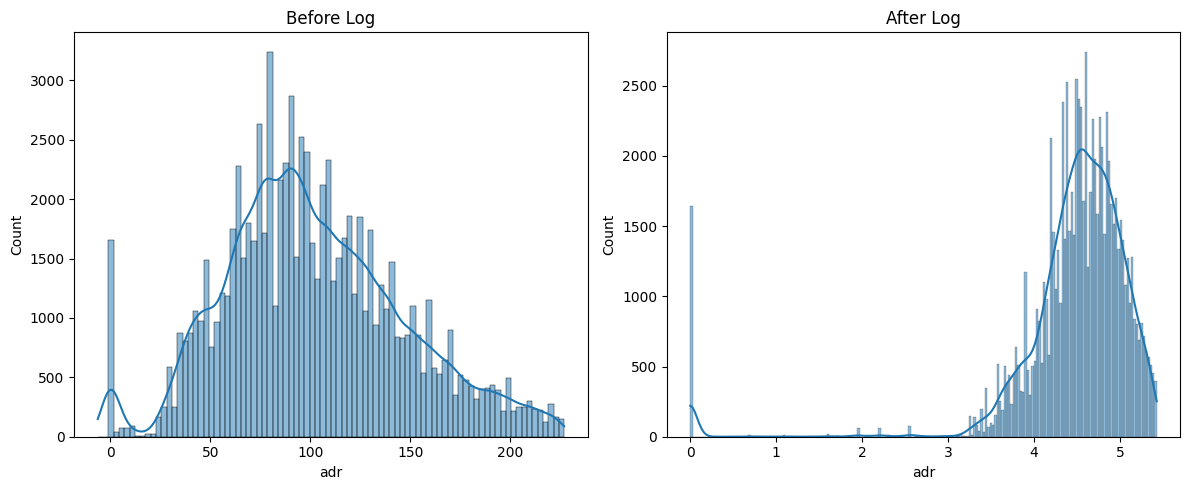

In [39]:
#compare distribution

plt.figure(figsize=(12,5))
#
plt.subplot(1,2,1)
sns.histplot(df["adr"], kde=True)

plt.title("Before Log")

plt.subplot(1,2,2)
sns.histplot(log_df["adr"], kde=True)

plt.title("After Log")

plt.tight_layout()
plt.show()

# FEATURE ENGINEERING

In [41]:
#Total Stay
processed_df["total_stay"] = (
    processed_df["stays_in_weekend_nights"] +
    processed_df["stays_in_week_nights"]
)
# Total Guests
processed_df["total_guests"] = (
    processed_df["adults"] +
    processed_df["children"] +
    processed_df["babies"]
)
# Lead Time Category
processed_df["lead_time_category"] = pd.cut(
    processed_df["lead_time"],
    bins=[-1,30,90,180,1000],
    labels=["Short","Medium","Long","Very Long"]
)
# Weekend Stay
processed_df["weekend_stay"] = np.where(
    processed_df["stays_in_weekend_nights"]>0,
    "Yes",
    "No"
)
# Average Daily Revenue
processed_df["average_daily_revenue"] = (
    processed_df["adr"] *
    processed_df["total_stay"]
)
# Booking Season
season = {
    "January":"Winter",
    "February":"Winter",
    "March":"Spring",
    "April":"Spring",
    "May":"Spring",
    "June":"Summer",
    "July":"Summer",
    "August":"Summer",
    "September":"Autumn",
    "October":"Autumn",
    "November":"Autumn",
    "December":"Winter"
}

processed_df["booking_season"] = df["arrival_date_month"].map(season)
#Family or Single Customer
processed_df["customer_group"] = np.where(
    processed_df["total_guests"]>2,
    "Family",
    "Individual/Couple"
)
#Cell 44 View New Features
processed_df[[
    "total_stay",
    "total_guests",
    "lead_time_category",
    "weekend_stay",
    "average_daily_revenue",
    "booking_season",
    "customer_group"
]].head()

,total_stay,total_guests,lead_time_category,weekend_stay,average_daily_revenue,booking_season,customer_group
0,0,2.0,Very Long,No,0.0,Summer,Individual/Couple
1,0,2.0,Very Long,No,0.0,Summer,Individual/Couple
2,1,1.0,Short,No,75.0,Summer,Individual/Couple
3,1,1.0,Short,No,75.0,Summer,Individual/Couple
4,2,2.0,Short,No,196.0,Summer,Individual/Couple


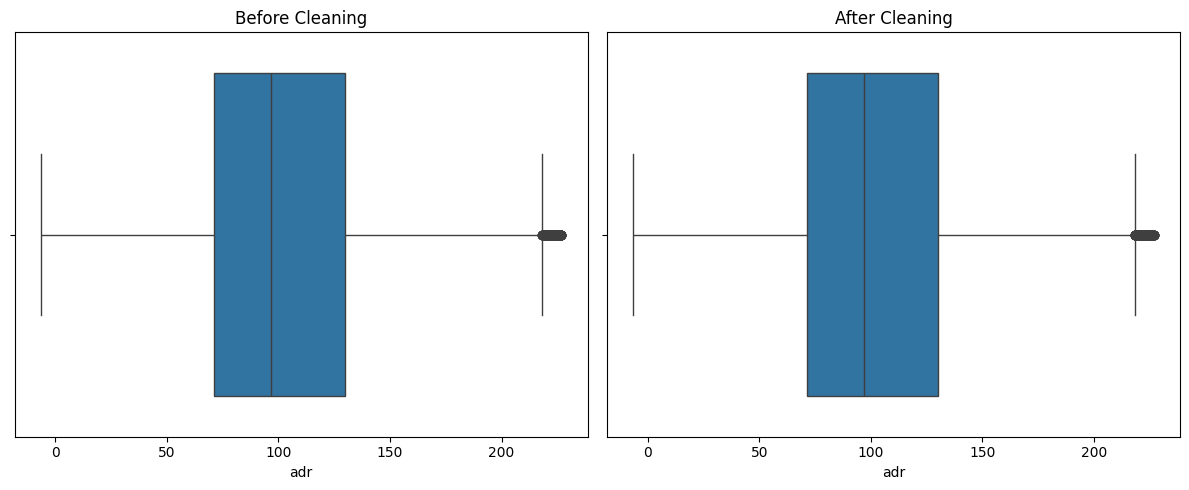

In [42]:
# ADR Before & After
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df["adr"])
plt.title("Before Cleaning")

plt.subplot(1,2,2)
sns.boxplot(x=processed_df["adr"])
plt.title("After Cleaning")

plt.tight_layout()
plt.show()

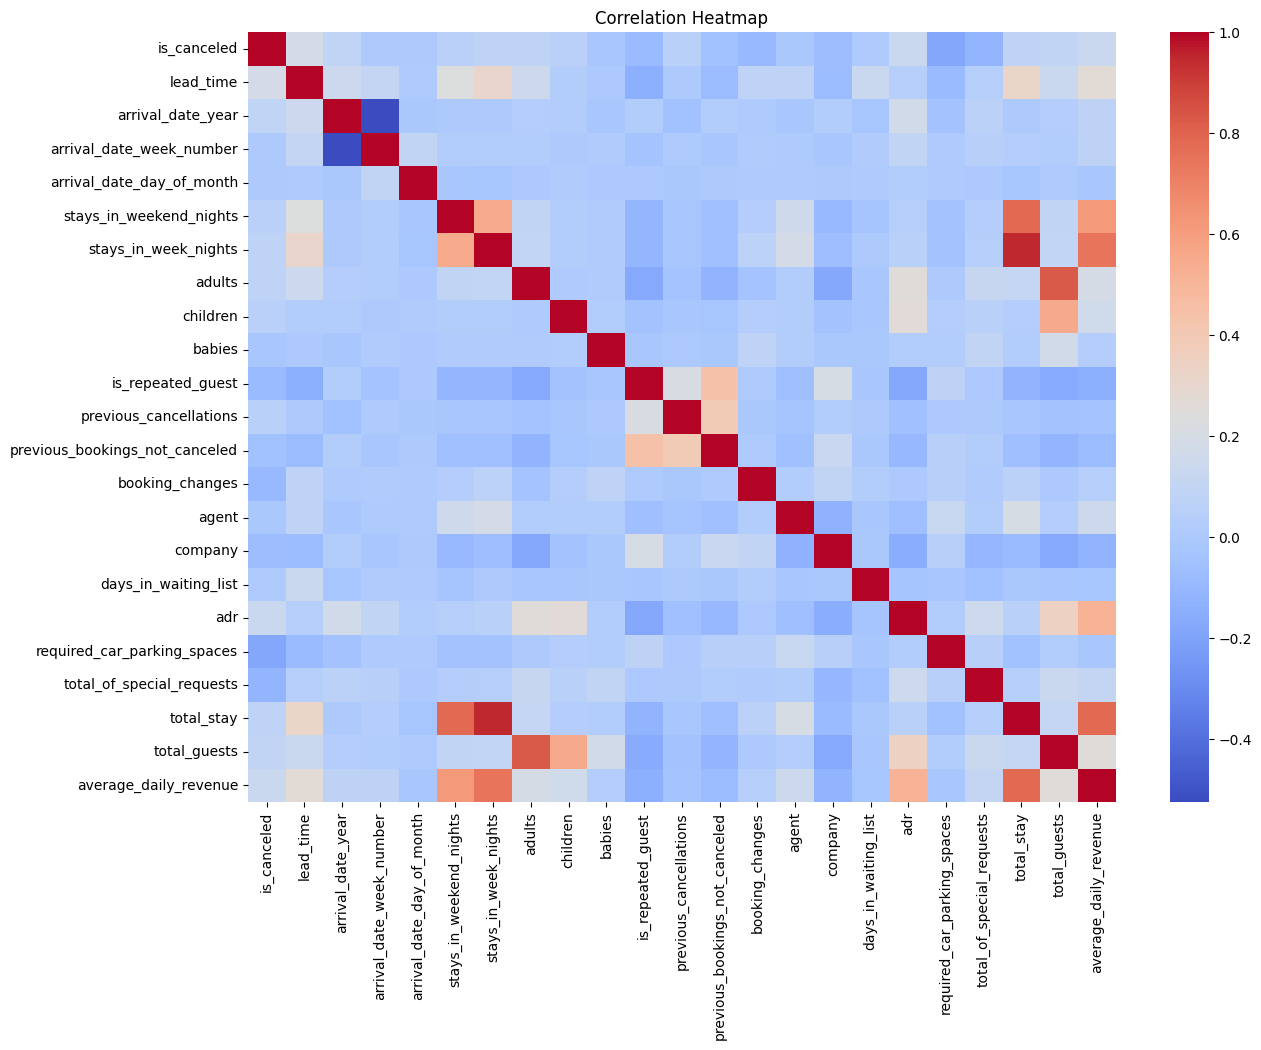

In [43]:
#Feature Correlation
plt.figure(figsize=(14,10))

sns.heatmap(
    processed_df.select_dtypes(include=["int64","float64"]).corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [44]:
#Final Shape
print("Final Dataset Shape :", processed_df.shape)

Final Dataset Shape : (84705, 39)


In [46]:
#Save Processed Dataset
processed_df.to_csv(
    "processed_hotel_bookings.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.
